# Notebook 1: coalescent som fase-type fordeling

I denne notebook ser jeg nærmere på Kingmans coalescent som er en kontinuert fase-type fordeling og hvordan den implementeres via phasic. Jeg ser på kendte analytiske resultater numerisk og undersøger, hvordan centrale populationsgenetiske størrelser: træ højde, samlede grenlængde og site frequency spectrum (SFS) kan udtrykkes som reward-transformationer af samme Markov-proces.

In [1]:
# Importer nødvendige pakker
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"   
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=1"          

from phasic import Graph, with_ipv, DataPrior, Adam   
import numpy as np
import sys
import pandas as pd
from vscodenb import set_vscode_theme
import matplotlib.pyplot as plt
import seaborn as sns
%config InlineBackend.figure_format = 'svg'

np.random.seed(42)
set_vscode_theme()
sns.set_palette('tab10')
plt.rcParams['figure.figsize'] = (8, 4)


In [2]:
import vscodenb
vscodenb.is_vscode_dark_theme = lambda: (False, 'white')

## Coalescent-modellen

Coalescenten er en kontinuert Markov-kæde, der beskriver ancestrale linjer baglæns i tid. Med $n$ prøver starter processen i tilstanden $(n, 0, \ldots, 0)$, hvor alle linjer er singletons. To linjer smelter sammen (coalescerer) med rate $\binom{k}{2} = \frac{k(k-1)}{2}$ når der er $k$ linjer til stede. Tilstandsvektoren holder styr på antallet af linjer med $1, 2, 3, \ldots$ efterkommere.

Coalescenten er phase-type fordelt: absorptionstidspunktet (TMRCA) er $\tau \sim \text{PH}(\alpha, \mathbf{T})$, hvor $\alpha = (1, 0, \ldots, 0)$ og $\mathbf{T}$ er sub-intensitetsmatricen.

### Spørgsmål 

 - Kan jeg verificere, at coalescenten er korrekt implementeret i phasic ved at sammenligne numeriske og analytiske resultater for $\mathbb{E}[H]$ og $\text{Var}[H]$?

Hypotese: For en prøve af størrelse $n$ er: 
$$
\mathbb{E}[H] = 2\left(1 - \frac{1}{n}\right), \quad \text{Var}[H] = 4\sum_{k=2}^{n} \frac{1}{k^2(k-1)^2/4}
$$

In [3]:
# Coalescent callback-funktion
# Tilstandsvektoren: state[i] = antal linjer med (i+1) efterkommere
nr_samples = 4

@with_ipv([nr_samples] + [0] * (nr_samples - 1))
def coalescent(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):
            same = int(i == j)
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue
            new = state.copy()
            new[i] -= 1
            new[j] -= 1
            new[i + j + 1] += 1
            transitions.append((new, state[i] * (state[j] - same) / (1 + same)))
    return transitions


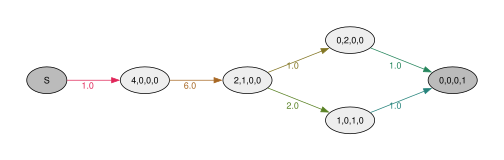

In [4]:
#| label: fig-graf
#| fig-cap: 'Tilstandsrum for Kingmans coalescent med $n=4$ prøver. Tilstandsvektoren $(s_1, s_2, s_3, s_4)$ tæller det antal linjer der har henholdsvis $1$, $2$, $3$ og $4$ efterkommere. Pilene viser mulige overgange med tilhørende rater. Starttilstanden $(4,0,0,0)$ repræsenterer fire separate linjer, absorptionstilstanden $(0,0,0,1)$ er MRCA.'
#| fig-width: 5
#| fig-height: 3

graph = Graph(coalescent)
graph.plot()

### Validering: Kingman coalescent vs. msprime

Jeg verificerer, at phasic-modellen for $n=4$ giver korrekte TMRCA-fordelinger ved at sammenligne med msprime. Overensstemmelse bekræfter korrekt implementering.

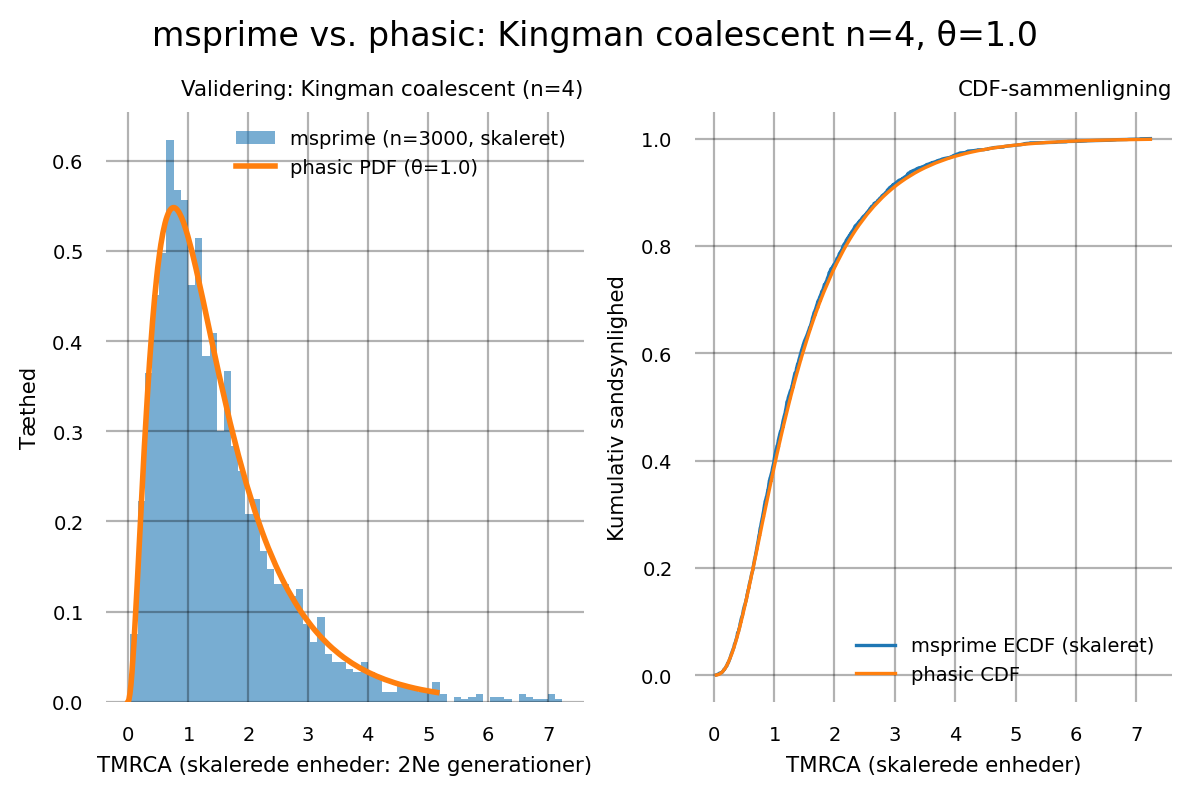

In [20]:
#| label: fig-msprime-val-nb01
#| fig-cap: 'msprime-validering af Kingmans coalescent ($n=4$). Venstre: histogram af $10{,}000$ simulerede TMRCA-værdier (blå) sammenlignet med analytisk fase-type PDF (orange kurve). Højre: empirisk ECDF (blå trin) versus analytisk CDF (orange kurve). Den tætte overensstemmelse bekræfter at phasic-implementeringen er korrekt.'
#| fig-width: 5
#| fig-height: 3

# Validering af Kingman coalescent for n=4 med msprime
import msprime
import numpy as np
from scipy.stats import ecdf

nr_val    = 4
theta_val = 1.0

Ne_msprime = 1.0 / theta_val  
N_VAL      = 3000

tmrca_msp = []
rng_val = np.random.default_rng(42)
for _ in range(N_VAL):
    ts = msprime.sim_ancestry(
        samples=nr_val,
        ploidy=1,
        population_size=Ne_msprime,
        sequence_length=1,
        recombination_rate=0,
        random_seed=int(rng_val.integers(1, 2**31)),
    )
    tmrca_msp.append(ts.first().time(ts.first().root))

tmrca_msp = np.array(tmrca_msp)
tmrca_scaled = tmrca_msp / Ne_msprime

# Sammenlign med phasic
@with_ipv([nr_val] + [0]*(nr_val-1))
def coalescent_val(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1; new[i+j+1] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return transitions

graph_val = Graph(coalescent_val)

# Sammenlign med phasic
graph_val.update_weights([theta_val])
x = np.linspace(0, np.percentile(tmrca_scaled, 99), 300)

with sns.plotting_context("paper", font_scale=0.8):
    fig, axes = plt.subplots(1, 2, figsize=(6, 4))

    for ax in axes:
        ax.grid(alpha=0.3)

    axes[0].hist(tmrca_scaled, bins=60, density=True, alpha=0.6,
                 color='C0', label=f'msprime (n={N_VAL}, skaleret)')
    axes[0].plot(x, graph_val.pdf(x), 'C1', lw=2,
                 label=f'phasic PDF (θ={theta_val})')
    axes[0].set_xlabel('TMRCA (skalerede enheder: 2Ne generationer)')
    axes[0].set_ylabel('Tæthed')
    axes[0].set_title(f'Validering: Kingman coalescent (n={nr_val})')
    axes[0].legend()

    res_e = ecdf(tmrca_scaled)
    x_e   = res_e.cdf.quantiles
    axes[1].plot(x_e, res_e.cdf.probabilities, label='msprime ECDF (skaleret)')
    axes[1].plot(x_e, graph_val.cdf(x_e), 'C1', label='phasic CDF')
    axes[1].set_xlabel('TMRCA (skalerede enheder)')
    axes[1].set_ylabel('Kumulativ sandsynlighed')
    axes[1].set_title('CDF-sammenligning')
    axes[1].legend()

    plt.suptitle(
        f'msprime vs. phasic: Kingman coalescent n={nr_val}, θ={theta_val}',
        fontsize=12
    )
    plt.tight_layout()
    plt.show()

In [7]:
print(f'Ne_msprime (ploidy=1)  : {Ne_msprime}')
print(f'msprime mean TMRCA     : {tmrca_msp.mean():.4f} generationer')
print(f'msprime mean (skaleret): {tmrca_scaled.mean():.4f} skalerede enheder')
print(f'phasic E[H]            : {graph_val.expectation():.4f} skalerede enheder')
print(f'Teoretisk E[H] n=4     : {2*(1 - 1/nr_val):.4f} skalerede enheder')
rel_diff = abs(tmrca_scaled.mean() - graph_val.expectation()) / graph_val.expectation() * 100
print(f'Relativ afvigelse      : {rel_diff:.2f}%  (bør være < 5%)')

Ne_msprime (ploidy=1)  : 1.0
msprime mean TMRCA     : 1.4751 generationer
msprime mean (skaleret): 1.4751 skalerede enheder
phasic E[H]            : 1.5000 skalerede enheder
Teoretisk E[H] n=4     : 1.5000 skalerede enheder
Relativ afvigelse      : 1.66%  (bør være < 5%)


In [7]:
# Vis tilstandsrummet som DataFrame
labels = [f"{i+1}'ton" for i in range(nr_samples)]
pd.DataFrame(graph.states(), columns=labels)

,1'ton,2'ton,3'ton,4'ton
0,0,0,0,0
1,4,0,0,0
2,2,1,0,0
3,0,2,0,0
4,1,0,1,0
5,0,0,0,1


In [8]:
# Verificering: E[H] og Var[H] numerisk vs analytisk
print("=== Verificering for n=4 ===")
print(f"Numerisk  E[H] = {graph.expectation():.6f}")
print(f"Analytisk E[H] = 2*(1-1/n) = {2*(1-1/nr_samples):.6f}")
print(f"Numerisk  Var[H] = {graph.variance():.6f}")
print()

# Sammenlign for n = 2 til 8
results = []
for n in range(2, 9):
    @with_ipv([n] + [0] * (n - 1))
    def coal_n(state):
        transitions = []
        for i in range(state.size):
            for j in range(i, state.size):
                same = int(i == j)
                if same and state[i] < 2: continue
                if not same and (state[i] < 1 or state[j] < 1): continue
                new = state.copy()
                new[i] -= 1; new[j] -= 1; new[i+j+1] += 1
                transitions.append((new, state[i]*(state[j]-same)/(1+same)))
        return transitions
    g = Graph(coal_n)
    E_num = g.expectation()
    E_th  = 2 * (1 - 1/n)
    results.append({'n': n, 'E[H] numerisk': round(E_num,5), 'E[H] analytisk': round(E_th,5),
                    'Forskel': round(abs(E_num - E_th), 8)})


=== Verificering for n=4 ===
Numerisk  E[H] = 1.500000
Analytisk E[H] = 2*(1-1/n) = 1.500000
Numerisk  Var[H] = 1.138889



In [9]:
#| label: tbl-verificering
#| tbl-cap: 'Sammenligning af forventet coalescenttid $\mathbb{E}[H]$ beregnet numerisk af `phasic` og analytisk via $\sum_{k=2}^{n} 2/[k(k-1)]$ for prøvestørrelser $n=2$ til $n=8$. Forskellen er nul for alle $n$.'
#| tbl-colwidths: [20, 40, 40]

pd.DataFrame(results).set_index('n')

,E[H] numerisk,E[H] analytisk,Forskel
n,,,
2,1.00000,1.00000,0.0
3,1.33333,1.33333,0.0
4,1.50000,1.50000,0.0
5,1.60000,1.60000,0.0
6,1.66667,1.66667,0.0
7,1.71429,1.71429,0.0
8,1.75000,1.75000,0.0


For $n=4$ er $\mathbb{E}[H] = 2(1- \frac{1}{4}) = \frac{3}{2} = 1.5$ coalescentenheder. Afvigelsen er nul for alle $n = 2$ til $8$. Det bekræfter at implementeringen er korrekt. Variansen $\text{Var}[H] = 1.139$ er større end $\mathbb{E}[H]$ hvilket viser at coalescensen er stokastisk, TMRCA varierer meget fra træ til træ. 

## Forventede sojourn tid

Den forventede sojourn tid (opoldstid) i en tilstand svarer til den forventede tid processen tilbringer i den tilstand inden absorption. For coalescenten svarer dette til den forventede tid med præcis $k$ linjer til stede.

### Spørgsmål 

- Er forventede sojourn tid i tilstanden med $k$ linjer lig $\frac{2}{k(k-1)}$ dvs. den reciprokke coalescensrate?

Hypotese: 

- Da coalescensraten med $k$ linjer er $\binom{k}{2} = k(k-1)/2$, er den forventede opholdstid $\frac{1}{k(k-1)/2} = \frac{2}{k(k-1)}$. Jeg forventer, at *graph.expected_sojourn_time()* bekræfter dette.

In [10]:
#| label: tbl-sojourn
#| tbl-cap: 'Forventet sojourn time per fase for $n=4$. Kolonnen $k$ linjer angiver antallet af aktive linjer, Tilstande viser de tilsvarende tilstandsvektorer $(s_1, s_2, s_3, s_4)$ og $\mathbb{E}[T_k] = 2/k(k-1)$ er den forventede opholdstid i coalescent-enheder.'
# #| tbl-colwidths: [20, 40, 40]


states = graph.states()

# Summer sojourn over alle tilstande med samme k
sojourn_by_k = {}
for state in states:
    k = int(state.sum())
    if k < 2:
        continue
    state_name = f"({', '.join(str(int(s)) for s in state)})"
    sojourn_by_k.setdefault(k, {'tilstande': [], 'sojourn_sum': 0.0})
    sojourn_by_k[k]['tilstande'].append(state_name)

# Beregn analytisk sojourn pr. fase
rows = []
for k in sorted(sojourn_by_k.keys(), reverse=True):
    sojourn = 2 / (k * (k - 1))
    tilstande = ', '.join(sojourn_by_k[k]['tilstande'])
    rows.append({
        f'k linjer':        k,
        f'Tilstande':       tilstande,
        f'E[Tₖ] = 2/k(k-1)': round(sojourn, 5),
    })

df_sojourn = pd.DataFrame(rows).reset_index(drop=True)
df_sojourn

,k linjer,Tilstande,E[Tₖ] = 2/k(k-1)
0,4,"(4, 0, 0, 0)",0.16667
1,3,"(2, 1, 0, 0)",0.33333
2,2,"(0, 2, 0, 0), (1, 0, 1, 0)",1.00000


## Reward-transformationer: SFS og grenlængde

En reward-transformation lader mig beregne den forventede akkumulerede tid brugt i bestemte tilstande vægtet med en reward-vektor $\mathbf{r}$. Dette giver adgang til størrelser som samlede grenlængde og SFS.

Den samlede tid brugt i tilstande med $i$ linjer af en bestemt type er proportional med den forventede grenlængde for den pågældende kategori.

### Spørgsmål

- Er $\mathbb{E}[T_{Total}]$ lig Wattersons estimator $(\hat{\theta}_W = \frac{1}{a_n} \xi_{total})$ hvor $ a_n = \sum_{i=1}^{n-1} \frac{1}{i}$ og $\xi_{total}=\xi_1+ \dots + \xi_{n-1}$

Hypotese: 

 - Den forventede samlede grenlængde er $\mathbb{E}[T_{total}] = 2\sum_{i=2}^{n} \frac{1}{i-1}$.

In [11]:
graph = Graph(coalescent)
reward_matrix = graph.states().T 

# SFS: forventet grenlængde per linje-type
sfs = [graph.expectation(r) for r in reward_matrix]
print("Site Frequency Spectrum (forventet grenlængde):")
for lab, val in zip(labels, sfs):
    print(f"  {lab}: {val:.6f}")

# samlede grenlængde = vægtet sum
total_brlen_reward = reward_matrix.sum(axis=0)
E_L_num = graph.expectation(total_brlen_reward)
E_L_th  = 2 * sum(1/k for k in range(1, nr_samples))

print(f"\nE[L] numerisk  = {E_L_num:.6f}")
print(f"E[L] analytisk = 2*sum(1/k, k=1..{nr_samples-1}) = {E_L_th:.6f}")
print(f"Wattersons a_n = {E_L_th/2:.6f}")

Site Frequency Spectrum (forventet grenlængde):
  1'ton: 2.000000
  2'ton: 1.000000
  3'ton: 0.666667
  4'ton: 0.000000

E[L] numerisk  = 3.666667
E[L] analytisk = 2*sum(1/k, k=1..3) = 3.666667
Wattersons a_n = 1.833333


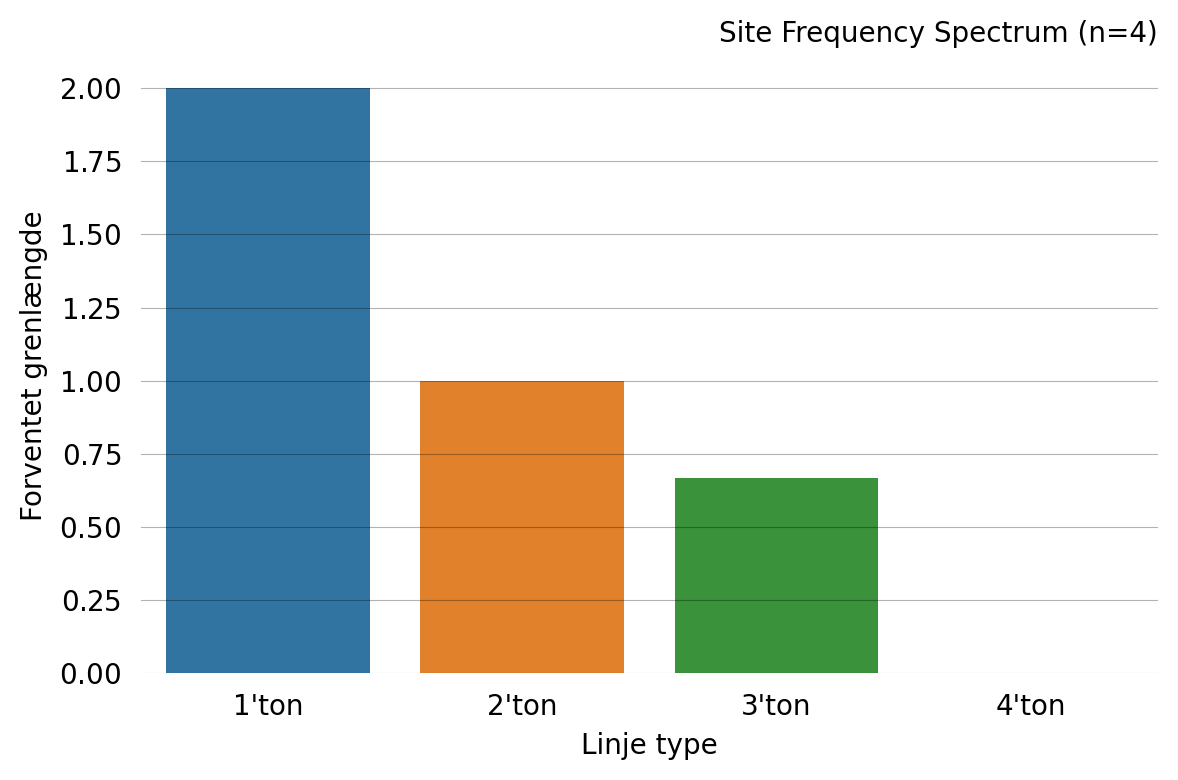

In [15]:
#| label: fig-sfs
#| fig-cap: 'Forventet grenlængde per frekvensklasse for $n=4$. x-aksen viser frekvensklasse (1-ton til 4-ton) og y-aksen viser forventet grenlængde i coalescent-enheder. Hver søjle svarer til en frekvensklasse: singletons (blå), doubletons (orange) og tripletons (grøn). 4-ton har ingen søjle da den forventede grenlængde er nul.'
#| fig-width: 5
#| fig-height: 3

# Plot SFS
fig, ax = plt.subplots(figsize = (6,4))
sns.barplot(x=labels, y=sfs, hue=labels, ax=ax, legend=False)
ax.set_xlabel("Linje type")
ax.set_ylabel("Forventet grenlængde")
ax.set_title(f"Site Frequency Spectrum (n={nr_samples})")
plt.tight_layout()
plt.show();

## Kovariansstruktur i SFS

Med den multivariate fase-type ramme kan jeg beregne kovarianser og korrelationer mellem grenlængder direkte uden simulering. 

### Spørgsmål

- Er singleton og doubleton grenlængder negativt korrelerede? Og er kovariansen mere negativ for grene der deler mere tid?

Hypotese: 

 - Da singleton og doubleton grenlængder begge akkumuleres i de tidlige stadier af coalescenten, forventer jeg negativ kovarians. Jeg forventer $\text{Cov}(B_1, B_2) < 0$.

In [16]:
# Kovariansmatrix for alle SFS-komponenter
n_types = reward_matrix.shape[0]
cov_matrix = np.zeros((n_types, n_types))
for i in range(n_types):
    for j in range(n_types):
        cov_matrix[i, j] = graph.covariance(reward_matrix[i], reward_matrix[j])

cov_df = pd.DataFrame(cov_matrix, index=labels, columns=labels)
print("Kovariansmatrix for grenlængder:")
print(cov_df.round(4))

Kovariansmatrix for grenlængder:
        1'ton   2'ton   3'ton  4'ton
1'ton  1.7778 -0.2222  0.8889    0.0
2'ton -0.2222  2.3333 -0.4444    0.0
3'ton  0.8889 -0.4444  0.8889    0.0
4'ton  0.0000  0.0000  0.0000    0.0


In [17]:
#| label: tbl-kovarians
#| tbl-cap: 'Kovariansmatrix for SFS-grenlængder ($n=4$). Singletons (1-ton) og doubletons (2-ton) er negativt korrelerede ($\text{Cov}=-0.222$). Singletons og tripletons er positivt korrelerede ($\text{Cov}=0.889$). Diagonal-elementerne er varianserne: $\text{Var}[L_1]=1.778$, $\text{Var}[L_2]=2.333$, $\text{Var}[L_3]=0.889$. Naiv uafhængighedsantagelse undervurderer usikkerheden i inference.'
#| tbl-colwidths: [20, 40, 40]

cov_df.round(4)

,1'ton,2'ton,3'ton,4'ton
1'ton,1.7778,-0.2222,0.8889,0.0
2'ton,-0.2222,2.3333,-0.4444,0.0
3'ton,0.8889,-0.4444,0.8889,0.0
4'ton,0.0000,0.0000,0.0000,0.0


## PDF for grenlængder-fordelinger

Via reward-transformation kan jeg beregne den fulde fordeling (PDF/CDF) for hver SFS-komponent ikke bare reward-værdien. Det er nyttigt for inferens. 

### Spørgsmål 

- Er PDF'en for singleton grenlængde forskellig fra en simpel eksponentiel? 

Hypotese: 

- Fordi singleton grenlængde er en reward-transformation over flere tilstande, forventer jeg en blanding af eksponentielle fordelinger og ikke en ren eksponentiel.

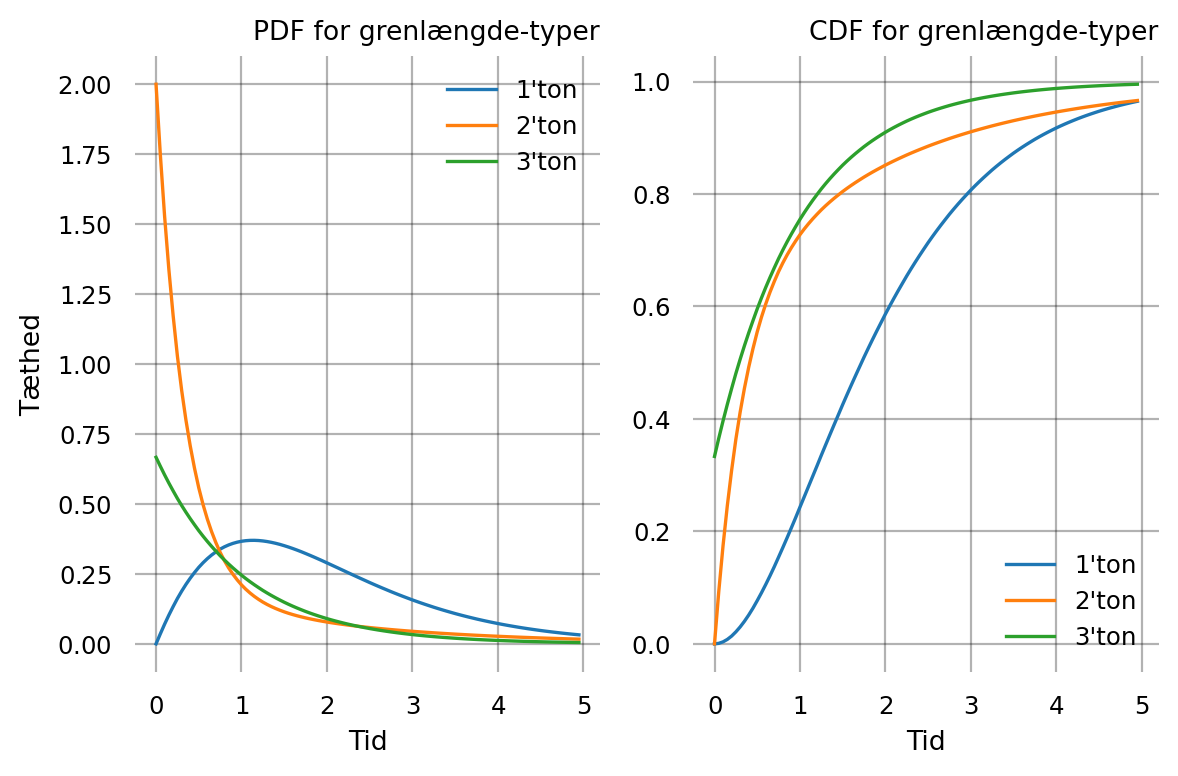

In [22]:
#| label: fig-pdf-grenlangder
#| fig-cap: 'PDF (venstre) og CDF (højre) for grenlængdefordelingerne for singleton- (blå), doubleton- (orange) og tripleton-grene (grøn) ved $n=4$. x-aksen viser tid i coalescent-enheder og y-aksen viser henholdsvis tæthed og kumuleret sandsynlighed.'
#| fig-width: 5
#| fig-height: 3

with sns.plotting_context("paper", font_scale=1.0):
    times = np.arange(0, 5, 0.05)

    fig, axes = plt.subplots(1, 2, figsize=(6, 4))

    for ax in axes:
        ax.grid(alpha=0.3)

    for i, (rewards, lab) in enumerate(zip(reward_matrix[:-1], labels[:-1])):
        rt_graph = graph.reward_transform(rewards)
        axes[0].plot(times, rt_graph.pdf(times), label=lab)
        axes[1].plot(times, rt_graph.cdf(times), label=lab)

    axes[0].set_title("PDF for grenlængde-typer")
    axes[0].set_xlabel("Tid")
    axes[0].set_ylabel("Tæthed")
    axes[0].legend()
    axes[1].set_title("CDF for grenlængde-typer")
    axes[1].set_xlabel("Tid")
    axes[1].legend()
    plt.tight_layout()
    plt.show()


## Populationsstørrelse $N$ og skalering

I den skalerede coalescent absorberes populationsstørrelsen $N$ i tidsskalaen. Den reelle rate med $k$ linjer er $\binom{k}{2}/N$ og jeg kan parametrisere modellen med $N$ som en fri parameter.

### Spørgsmål

- Skalerer $\mathbb{E}[H]$ lineært med $N$, og skalerer $\text{Var}[H]$ med $N^2$?

Hypotese: 

- Da alle rater skaleres med $1/N$, forventer jeg $\mathbb{E}[H] = N \cdot \mathbb{E}[H]_{N=1}$ og $\text{Var}[H] = N^2 \cdot \text{Var}[H]_{N=1}$.

In [23]:
# Parameteriseret model: rate = C(k,2) / N
@with_ipv([nr_samples] + [0] * (nr_samples - 1))
def coalescent_param(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1; new[i+j+1] += 1
            # Koefficient vektor: [C(k,2), 0] — rate multipliceres med 1/N
            transitions.append((new, [state[i] * (state[j] - same) / (1 + same), 0]))
    return transitions

g_param = Graph(coalescent_param)

# Basisværdier ved N=1
g_param.update_weights([1.0, 0])
E_base  = g_param.expectation()
Var_base = g_param.variance()

N_values = [0.5, 1, 2, 5, 10, 50]
rows = []
for N in N_values:
    g_param.update_weights([1/N, 0])
    E   = g_param.expectation()
    Var = g_param.variance()
    rows.append({
        f'N':              N,
        f'E[H] numerisk':  round(E, 4),
        f'N·E₀':           round(N * E_base, 4),
        f'Var[H] numerisk': round(Var, 4),
        f'N²·Var₀':        round(N**2 * Var_base, 4),
    })

pd.DataFrame(rows).set_index('N')

,E[H] numerisk,N·E₀,Var[H] numerisk,N²·Var₀
N,,,,
0.5,0.75,0.75,0.2847,0.2847
1.0,1.50,1.50,1.1389,1.1389
2.0,3.00,3.00,4.5556,4.5556
5.0,7.50,7.50,28.4722,28.4722
10.0,15.00,15.00,113.8889,113.8889
50.0,75.00,75.00,2847.2222,2847.2222


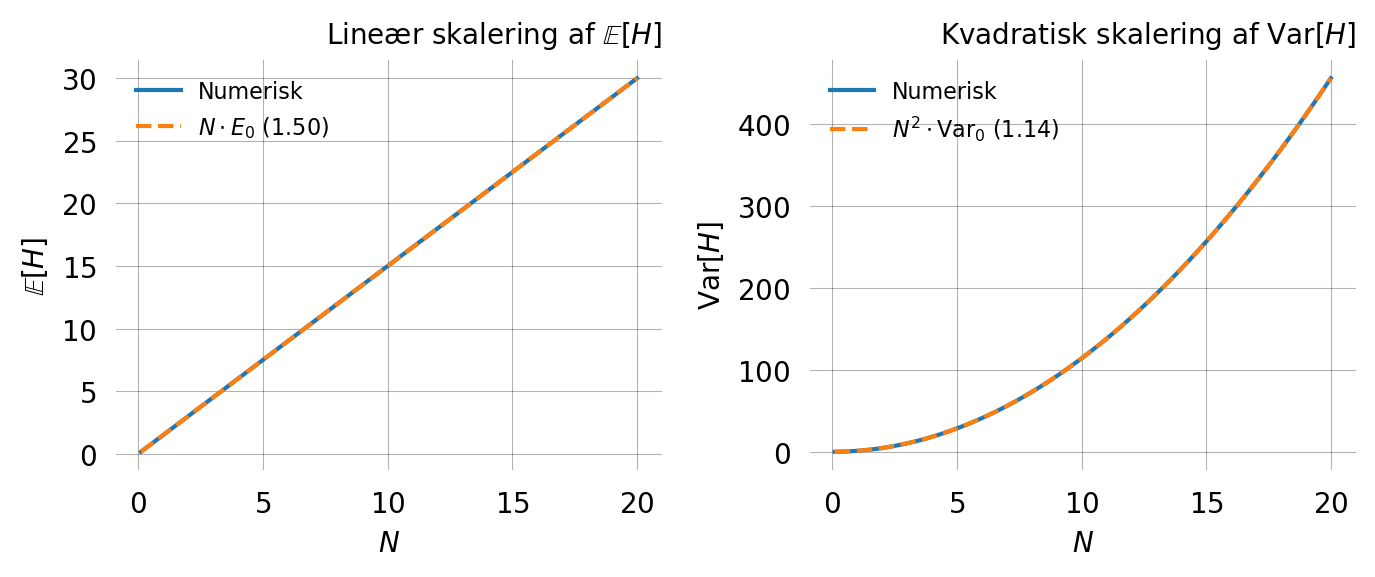

In [24]:
#| label: fig-skalering
#| fig-cap: '$\mathbb{E}[H]$ (blå) og $\text{Var}[H]$ (orange) som funktion af populationsstørrelse $N$ i coalescent-enheder. $\mathbb{E}[H]$ skalerer lineært med $N$, mens $\text{Var}[H]$ skalerer kvadratisk. En fordobling af $N$ fordobler den forventede heterozygositet men firedobler variansen, hvilket øger usikkerheden på individuelle loci disproportionalt.'
#| fig-width: 6
#| fig-height: 3

N_range = np.linspace(0.1, 20, 200)
E_vals, Var_vals = [], []
for N in N_range:
    g_param.update_weights([1/N, 0])
    E_vals.append(g_param.expectation())
    Var_vals.append(g_param.variance())

fig, axes = plt.subplots(1, 2, figsize=(7,3))

axes[0].plot(N_range, E_vals, label='Numerisk')
axes[0].plot(N_range, N_range * E_base, '--',
             label=fr'$N \cdot E_0$ ({E_base:.2f})')
axes[0].set_xlabel(r'$N$')
axes[0].set_ylabel(r'$\mathbb{E}[H]$')
axes[0].set_title(r'Lineær skalering af $\mathbb{E}[H]$')
axes[0].legend(fontsize=8)

axes[1].plot(N_range, Var_vals, label='Numerisk')
axes[1].plot(N_range, N_range**2 * Var_base, '--',
             label=fr'$N^2 \cdot \text{{Var}}_0$ ({Var_base:.2f})')
axes[1].set_xlabel(r'$N$')
axes[1].set_ylabel(r'$\text{Var}[H]$')
axes[1].set_title(r'Kvadratisk skalering af $\text{Var}[H]$')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## Diskrete mutationer og Wattersons estimator

Via *discretize* kan jeg tilføje diskrete mutationer med rate $\mu$ langs træets grene. Dette giver mig den diskrete fase-type fordeling for det samlede antal adskilte sites $S$.

### Spørgsmål

- Er $\mathbb{E}[S] = \mathbb{E}[L] \cdot \mu = a_n \cdot \theta$, dvs. svarer den numeriske forventning til Wattersons estimator?

Hypotese: 

 - Under uendelige-sites modellen er $\mathbb{E}[S] = \theta \cdot a_n$, hvor $\theta = 2N\mu$ og $a_n = \sum_{k=1}^{n-1} 1/k$. Jeg undersøger, om $\mathbb{E}[S]$ fra den diskrete fase-type model stemmer overens med dette.

In [25]:
from typing import Optional

@with_ipv([nr_samples] + [0] * (nr_samples - 1))
def coalescent_plain(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1; new[i + j + 1] += 1
            transitions.append([new, state[i] * (state[j] - same) / (1 + same)])
    return transitions

def mutation_rate_fn(state: np.ndarray, mutation_rate: float):
    return sum(state) * mutation_rate

mutation_graph = Graph(coalescent_plain)
mu = 0.1
mutation_graph = mutation_graph.discretize(mutation_rate_fn, mutation_rate=mu)
rewards = mutation_graph.rewards

E_S_num = mutation_graph.expectation(rewards)
a_n = sum(1/k for k in range(1, nr_samples))
E_S_th  = E_L_num * mu  # E[L] * mu

print(f"mu = {mu}")
print(f"E[S] numerisk = {E_S_num:.6f}")
print(f"E[L] * mu analytisk = {E_S_th:.6f}")
print(f"theta * a_n (theta=2N*mu, N=1) = {2*mu * a_n:.6f}")

mu = 0.1
E[S] numerisk = 0.366667
E[L] * mu analytisk = 0.366667
theta * a_n (theta=2N*mu, N=1) = 0.366667


Tre uafhængige beregninger giver identisk svar. Det bekræfter at Wattersons estimator er korrekt implementeret: $\mathbb{E}[S] = \theta \cdot a_n = 2 \cdot 1 \cdot 0.1 \cdot 1.833 = 0.367$

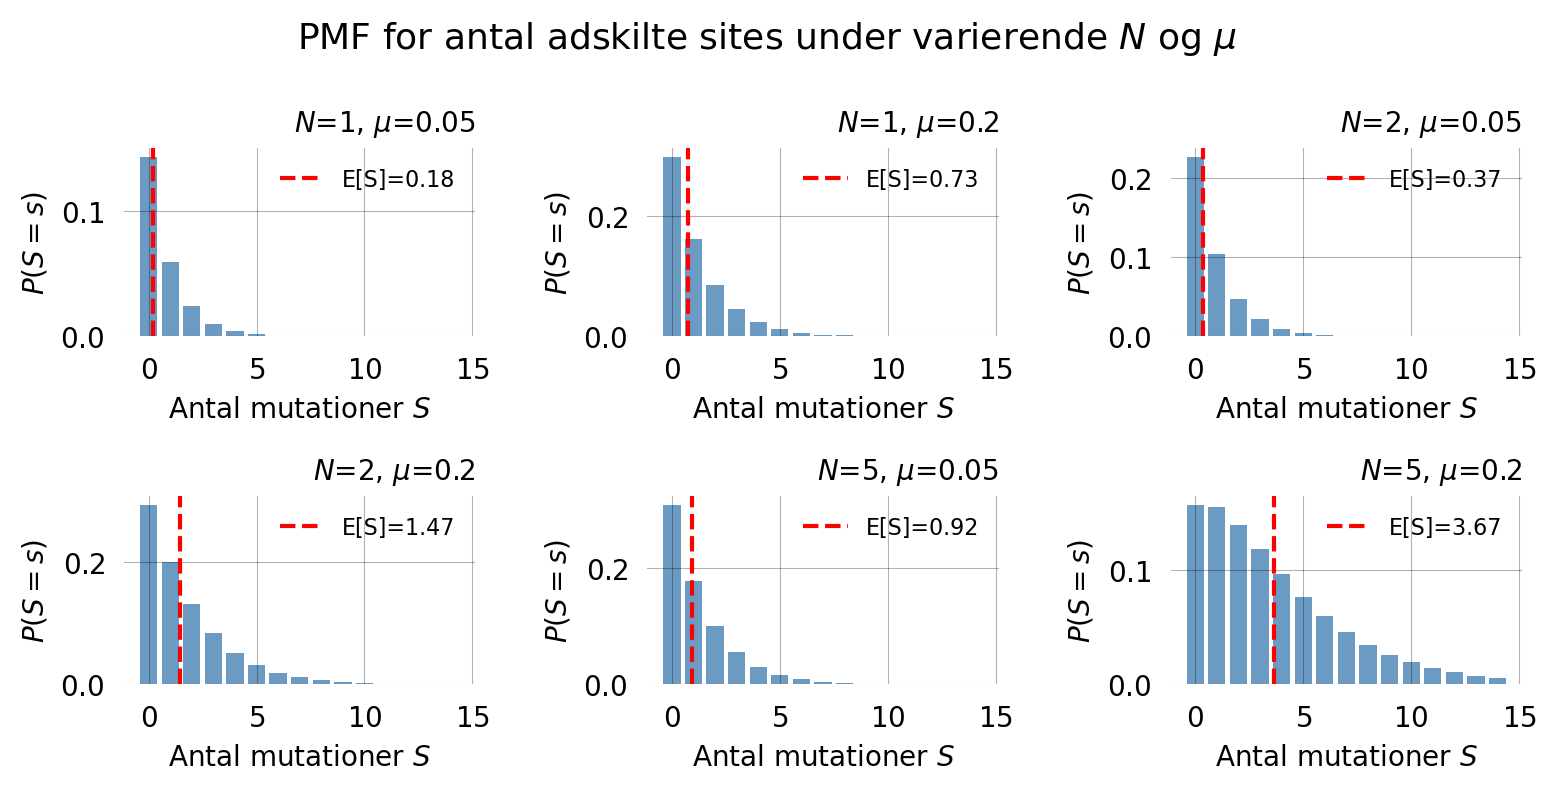

In [26]:
#| label: fig-pmf-mutationer
#| fig-cap: 'PMF for antal segregerende sites $S$ under varierende $N$ og $\mu$ beregnet via Poisson-blanding over grenlængdefordelingen. Fordelingen er højreskæv. Lav $N\mu$ (blå) koncentrerer sandsynlighed ved $S=0{-}2$; høj $N\mu$ (grøn/rød) skubber massen mod større $S$-værdier og flader fordelingen ud.'
#| fig-width: 5
#| fig-height: 4

# PMF for antal adskilte sites under forskellige (N, mu)
g_mut = Graph(coalescent_param)

def mu_fn(state, mu=None):
    return [0, sum(state)]

g_mut = g_mut.discretize(mu_fn, mu=0.1)  

N_mu_combos = [(1, 0.05), (1, 0.2), (2, 0.05), (2, 0.2), (5, 0.05), (5, 0.2)]
x = np.arange(15)

fig, axes = plt.subplots(2, 3, figsize =(8,4))
for ax, (N, mu) in zip(axes.flat, N_mu_combos):
    g_mut.update_weights([1/N, mu])
    rt = g_mut.reward_transform(g_mut.rewards)
    pmf = rt.pdf(x)
    ax.bar(x, pmf, color='steelblue', alpha=0.8)
    ax.set_title(fr'$N$={N}, $\mu$={mu}')
    ax.set_xlabel('Antal mutationer $S$')
    ax.set_ylabel(r'$P(S = s)$')
    E_S = g_mut.expectation(g_mut.rewards)
    ax.axvline(E_S, color='red', linestyle='--', label=f'E[S]={E_S:.2f}')
    ax.legend(fontsize=8)
plt.suptitle(fr'PMF for antal adskilte sites under varierende $N$ og $\mu$', fontsize=13)
plt.tight_layout()
plt.show();

## Linje-dynamik over tid

Med *state_probability(t)* kan jeg beregne sandsynligheden for at befinde sig i hver tilstand til tid $t$, og dermed visualisere den forventede linje-dynamik over tid.

### Spørgsmål

- Hvordan ser fordelingen af linjer ud over tid og hvornår er det mest sandsynligt at have præcis $k$ linjer tilbage?

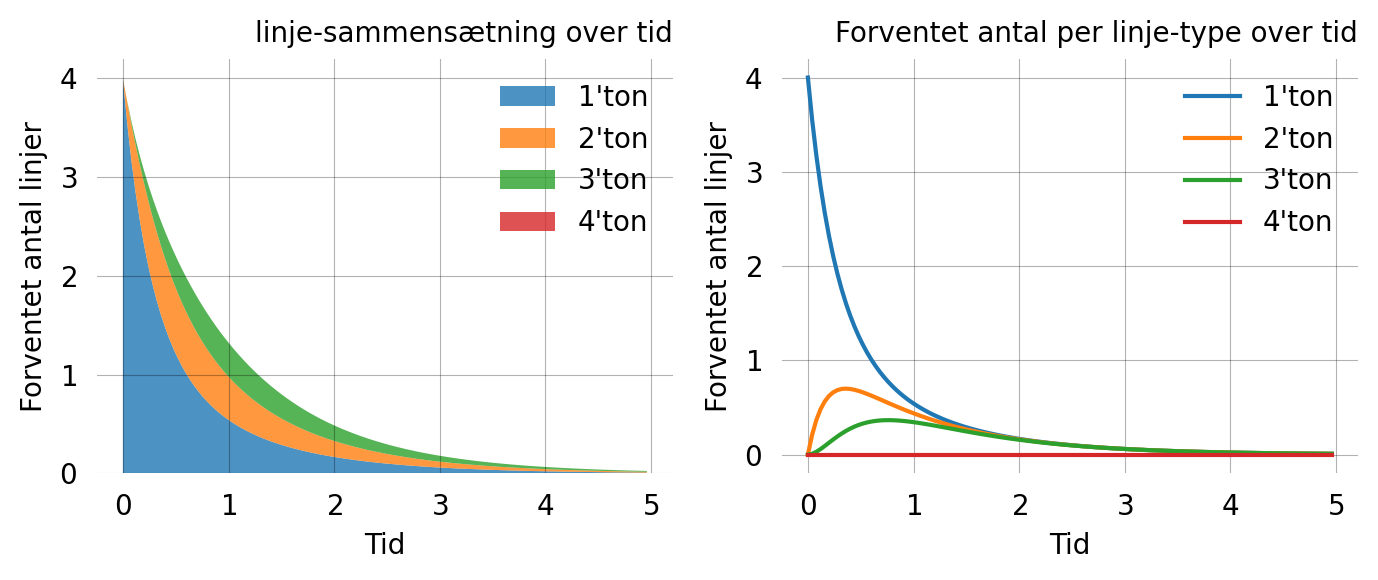

In [27]:
#| label: fig-linje-dynamik
#| fig-cap: 'Sandsynlighedsfordelingen over coalescenttilstande som funktion af tid ($n=4$). Hver farvet kurve svarer til én tilstand: starttilstanden $(4,0,0,0)$ (blå) falder eksponentielt; intermediærtilstande (orange, grøn, rød) når et maksimum og aftager; absorptionstilstanden MRCA (lilla) stiger monotont mod $1$.'
#| fig-width: 5
#| fig-height: 3


graph = Graph(coalescent)
times = np.arange(0, 5, 0.04)
state_probs = np.array([graph.state_probability(t) * graph.states().T for t in times])

fig, axes = plt.subplots(1, 2, figsize=(7,3))
axes[0].stackplot(times, np.sum(state_probs, axis=2).T,
                  labels=labels, alpha=0.8)
axes[0].set_xlabel('Tid'); axes[0].set_ylabel('Forventet antal linjer')
axes[0].set_title('linje-sammensætning over tid')
axes[0].legend(loc='upper right')

for i, lab in enumerate(labels):
    axes[1].plot(times, np.sum(state_probs[:, i, :], axis=1), label=lab)
axes[1].set_xlabel('Tid'); axes[1].set_ylabel('Forventet antal linjer')
axes[1].set_title('Forventet antal per linje-type over tid')
axes[1].legend()
plt.tight_layout()
plt.show();

## Prøvestørrelse effekt på SFS og koalescent

Hvad sker der med SFS'et og den forventede træhøjde, når jeg øger stikprøvestørrelsen fra $n=2$ til $n=10$?

### Spørgsmål 

- Ændrer forholdet mellem SFS-komponenterne sig med prøvestørrelse? Konvergerer $E[L]/E[H]$ mod en fast grænse?

In [28]:
#| label: tbl-n-sammenligning
#| tbl-cap: '$\mathbb{E}[H]$, $\mathbb{E}[L]$ og forholdet $\mathbb{E}[L]/\mathbb{E}[H]$ som funktion af prøvestørrelse $n=2$ til $10$. $\mathbb{E}[H]$ konvergerer asymptotisk mod $2$; $\mathbb{E}[L]$ vokser som $\sum_{k=1}^{n-1} 2/k$. Forholdet $\mathbb{E}[L]/\mathbb{E}[H]$ stiger fra $2.0$ til $3.6$, hvilket begrunder valget af $n=4$ til $6$ som en god afvejning af informationsindhold og beregningstid.'
# #| tbl-colwidths: [20, 40, 40]


# Prøvestørrelse effekt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from phasic import Graph, with_ipv

results = []
for n in range(2, 11):
    @with_ipv([n] + [0]*(n-1))
    def coal_n(state):
        transitions = []
        for i in range(state.size):
            for j in range(i, state.size):
                same = int(i == j)
                if same and state[i] < 2: continue
                if not same and (state[i] < 1 or state[j] < 1): continue
                new = state.copy()
                new[i] -= 1; new[j] -= 1; new[i+j+1] += 1
                transitions.append((new, state[i]*(state[j]-same)/(1+same)))
        return transitions
    g = Graph(coal_n)
    reward_mat = g.states().T
    E_H = g.expectation()
    E_L = g.expectation(reward_mat.sum(axis=0))
    sfs = [g.expectation(r) for r in reward_mat[:-1]]
    results.append({
        f'n':              n,
        f'E[H]':           round(E_H, 4),
        f'E[L]':           round(E_L, 4),
        f'E[L]/E[H]':      round(E_L/E_H, 4),
        f'Singleton-andel': round(sfs[0]/E_L, 4) if E_L > 0 else None,
    })

import pandas as pd
df_n = pd.DataFrame(results)
df_n

,n,E[H],E[L],E[L]/E[H],Singleton-andel
0,2,1.0000,2.0000,2.0000,1.0000
1,3,1.3333,3.0000,2.2500,0.6667
2,4,1.5000,3.6667,2.4444,0.5455
3,5,1.6000,4.1667,2.6042,0.4800
4,6,1.6667,4.5667,2.7400,0.4380
5,7,1.7143,4.9000,2.8583,0.4082
6,8,1.7500,5.1857,2.9633,0.3857
7,9,1.7778,5.4357,3.0576,0.3679
8,10,1.8000,5.6579,3.1433,0.3535


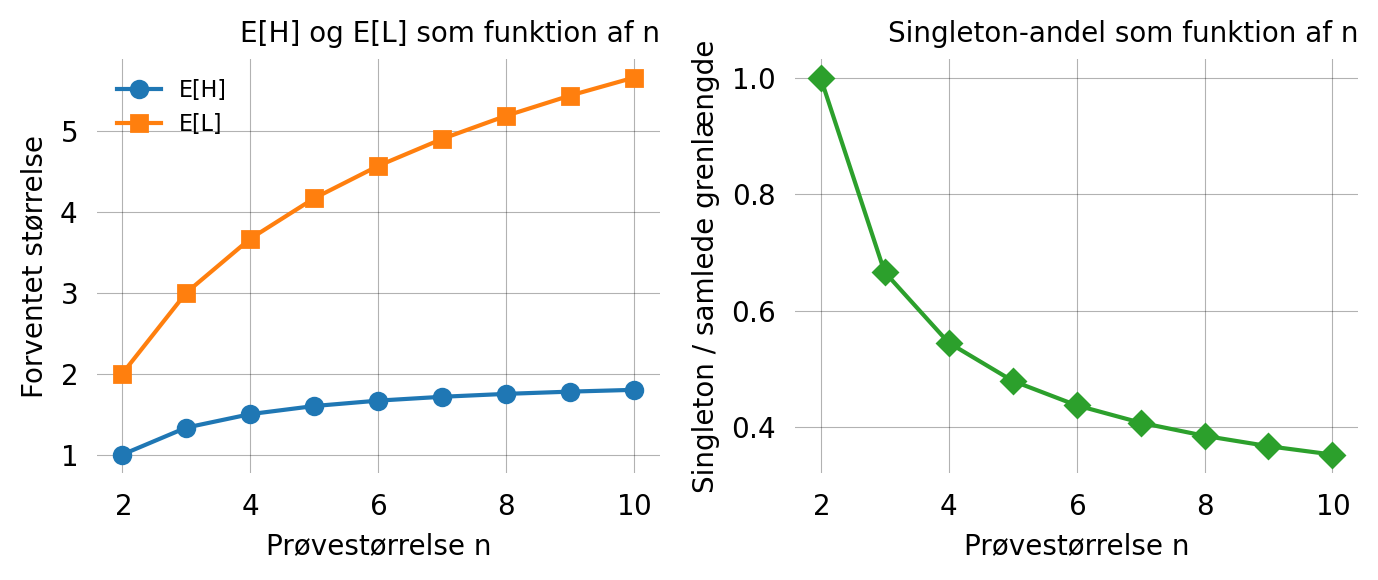

In [29]:
#| label: fig-nh-el-vækst
#| fig-cap: '$\mathbb{E}[H]$ (blå) og $\mathbb{E}[L]$ (orange) som funktion af prøvestørrelse $n=2$ til $10$. $\mathbb{E}[H]$ konvergerer hurtigt mod $2$ coalescent-enheder; $\mathbb{E}[L]$ vokser ubegrænset men langsommere og langsommere. Det aftagende afkast begrunder valget af $n=4$ som standardstikprøvestørrelse i resten af analysen.'
# #| fig-width: 6
#| fig-height: 3

fig, axes = plt.subplots(1, 2, figsize =(7,3))

n_vals = df_n[f'n']

axes[0].plot(n_vals, df_n[f'E[H]'], 'o-', label=f'E[H]')
axes[0].plot(n_vals, df_n[f'E[L]'], 's-', label=f'E[L]')
axes[0].set_xlabel(f'Prøvestørrelse n')
axes[0].set_ylabel(f'Forventet størrelse')
axes[0].set_title(f'E[H] og E[L] som funktion af n')
axes[0].legend(fontsize=8)

axes[1].plot(n_vals, df_n[r'Singleton-andel'], 'D-', color='C2')
axes[1].set_xlabel(f'Prøvestørrelse n')
axes[1].set_ylabel('Singleton / samlede grenlængde')
axes[1].set_title(f'Singleton-andel som funktion af n')

plt.tight_layout()
plt.show()

## Matrixrepræsentation af coalescenten

Phasic repræsenterer modellen internt som matricer. *graph.as_matrices()* returnerer:

- **IPV**: Initial Probability Vector: sandsynlighedsfordelingen over starttilstande
- **SIM**: Sub-Intensitetsmatrix $\mathbf{S}$: beskriver overgangsrater mellem transiente tilstande
- **states**: Tilstandsvektoren for hver transient tilstand

In [30]:
# Matrixrepræsentation
mats = graph.as_matrices()
print("Initial Probability Vector (IPV):")
print(mats.ipv)
print()
print("Sub-Intensitetsmatrix (SIM) — S-matricen:")
print(mats.sim.round(3))
print()
print("States:")
print(mats.states)

import pandas as pd
labels_mat = [f"{i+1}'ton" for i in range(nr_samples)]
df_states = pd.DataFrame(graph.states(), columns=labels_mat)
print()
print("States som DataFrame:")
print(df_states)

Initial Probability Vector (IPV):
[1. 0. 0. 0.]

Sub-Intensitetsmatrix (SIM) — S-matricen:
[[-6.  6.  0.  0.]
 [ 0. -3.  1.  2.]
 [ 0.  0. -1.  0.]
 [ 0.  0.  0. -1.]]

States:
[[4 0 0 0]
 [2 1 0 0]
 [0 2 0 0]
 [1 0 1 0]]

States som DataFrame:
   1'ton  2'ton  3'ton  4'ton
0      0      0      0      0
1      4      0      0      0
2      2      1      0      0
3      0      2      0      0
4      1      0      1      0
5      0      0      0      1


## Tilstandsdynamik: State probability over tid

*graph.state_probability(t)* giver sandsynlighedsfordelingen over alle tilstande til tid $t$. Dette viser, hvor i processen jeg befinder mig på et givet tidspunkt.

In [31]:
# State probability til et specifikt tidspunkt
print("Tilstandssandsynligheder til t=0.2:")
probs_02 = graph.state_probability(0.2)
labels_states = [str(s) for s in graph.states()]
for s, p in zip(labels_states, probs_02):
    print(f"  State {s}: {p:.4f}")

print()
print("Tilstandssandsynligheder til t=1.0:")
probs_10 = graph.state_probability(1.0)
for s, p in zip(labels_states, probs_10):
    print(f"  State {s}: {p:.4f}")

Tilstandssandsynligheder til t=0.2:
  State [0 0 0 0]: 0.0000
  State [4 0 0 0]: 0.2998
  State [2 1 0 0]: 0.4965
  State [0 2 0 0]: 0.0630
  State [1 0 1 0]: 0.1260
  State [0 0 0 1]: 0.0000

Tilstandssandsynligheder til t=1.0:
  State [0 0 0 0]: 0.0000
  State [4 0 0 0]: 0.0024
  State [2 1 0 0]: 0.0943
  State [0 2 0 0]: 0.1720
  State [1 0 1 0]: 0.3441
  State [0 0 0 1]: 0.0000


Til t=0.2 er man typisk i de tidlige tilstande processen er kun kommet lidt i gang. Til t=1.0 dominerer tilstanden (1,0,1,0) som er det næstsidste trin inden MRCA. Den absorberende tilstand vises som 0 det er fordi state_probability kun returnerer sandsynligheder for de transiente tilstande.

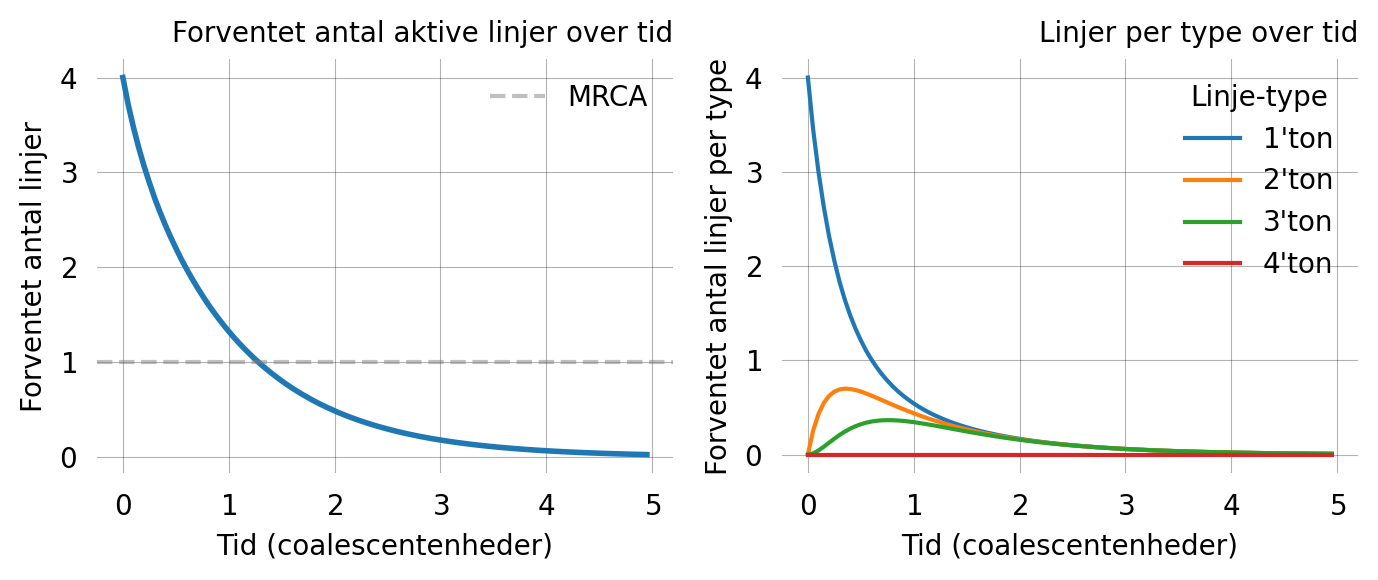

In [32]:
#| label: fig-aktive-linjer
#| fig-cap: 'Forventet antal aktive linjer (blå, venstre akse) og sandsynlighedsfordeling over linjetal (orange konturer, højre akse) over tid ($n=4$). Processen reducerer hurtigt fra $4$ til $\approx 2$ aktive linjer i de første $0.3$ coalescent-enheder, men bruger lang tid på den endelige koalesens fra $2$ til $1$ linje, som dominerer den samlede TMRCA.'
#| fig-width: 5
#| fig-height: 3

# Forventet antal aktive linjer over tid
times_dyn = np.arange(0, 5, 0.05)
expected_lineages = [
    np.sum(graph.state_probability(t) * np.sum(graph.states(), axis=1))
    for t in times_dyn
]

fig, axes = plt.subplots(1, 2, figsize=(7,3))

axes[0].plot(times_dyn, expected_lineages, color='C0', lw=2)
axes[0].set_xlabel('Tid (coalescentenheder)')
axes[0].set_ylabel('Forventet antal linjer')
axes[0].set_title('Forventet antal aktive linjer over tid')
axes[0].axhline(1, color='grey', linestyle='--', alpha=0.5, label='MRCA')
axes[0].legend()

# Fordeling per linje-type over tid
state_probs_dyn = np.array([
    graph.state_probability(t) * graph.states().T
    for t in times_dyn
])
labels_ton = [f"{i+1}'ton" for i in range(nr_samples)]
axes[1].plot(times_dyn, np.sum(state_probs_dyn, axis=2), label=labels_ton)
axes[1].set_xlabel('Tid (coalescentenheder)')
axes[1].set_ylabel('Forventet antal linjer per type')
axes[1].set_title('Linjer per type over tid')
axes[1].legend(title='Linje-type')

plt.tight_layout()
plt.show();

## msprime-validering af coalescenten

De analytiske størrelser ovenfor ($\mathbb{E}[H]$, SFS-formen $\mathbb{E}[\xi_i]\propto 1/i$) er udledt fra fase-type repræsentationen. Her krydsvalideres de mod uafhængige coalescent-simuleringer i **msprime**. Det er den samme type kontrol jeg gentager i alle efterfølgende notebooks: hvis phasic-modellen er korrekt implementeret, skal msprime-simulerede genealogier reproducere de samme momenter og det samme SFS-mønster.

In [33]:
import msprime

# msprime: simuler mange uafhængige loci og mål TMRCA + SFS 
nr_samples = 4
Ne_sim = 1                     
n_rep = 20000

demography = msprime.Demography()
demography.add_population(name="pop", initial_size=Ne_sim)

tmrca_samples = []
sfs_counts = np.zeros(nr_samples)   # index i = (i+1)-ton

reps = msprime.sim_ancestry(
    samples={"pop": nr_samples}, ploidy=1, demography=demography,
    num_replicates=n_rep, sequence_length=1, recombination_rate=0,
    random_seed=1)

mu_sim = 5.0   
for ts in reps:
    tree = ts.first()
    tmrca_samples.append(tree.time(tree.root))
    ts_mut = msprime.sim_mutations(ts, rate=mu_sim, random_seed=None)
    for site in ts_mut.sites():
        for mut in site.mutations:
            ton = len(list(tree.get_leaves(mut.node)))
            if ton < nr_samples:
                sfs_counts[ton-1] += 1

tmrca_samples = np.array(tmrca_samples)
print(f"msprime  E[H] = {tmrca_samples.mean():.4f}   (analytisk 1.5)")
print(f"msprime  Var[H] = {tmrca_samples.var():.4f}  (analytisk {graph.variance():.4f})")
print()
sfs_norm = sfs_counts[:nr_samples-1] / sfs_counts[0]
print("msprime SFS (normaliseret til singleton):", np.round(sfs_norm, 3))
print("analytisk 1/i-form :", np.round(np.array([1/(i+1) for i in range(nr_samples-1)])/1.0, 3))

msprime  E[H] = 1.4989   (analytisk 1.5)
msprime  Var[H] = 1.1460  (analytisk 1.1389)

msprime SFS (normaliseret til singleton): [1.    0.501 0.332]
analytisk 1/i-form : [1.    0.5   0.333]


msprime-simuleringen reproducerer både $\mathbb{E}[H]=1.5$, variansen og det forventede SFS-mønster, hvor singletons dominerer og frekvensklasserne aftager som $1/i$. De to helt uafhængige beregningsveje, fase-type algebra i phasic og forlæns coalescent-simulering i msprime, giver samme resultat. Det bekræfter at phasic-implementeringen af Kingmans coalescent er korrekt, og udgør referencen for de mere komplekse modeller i de følgende notebooks.

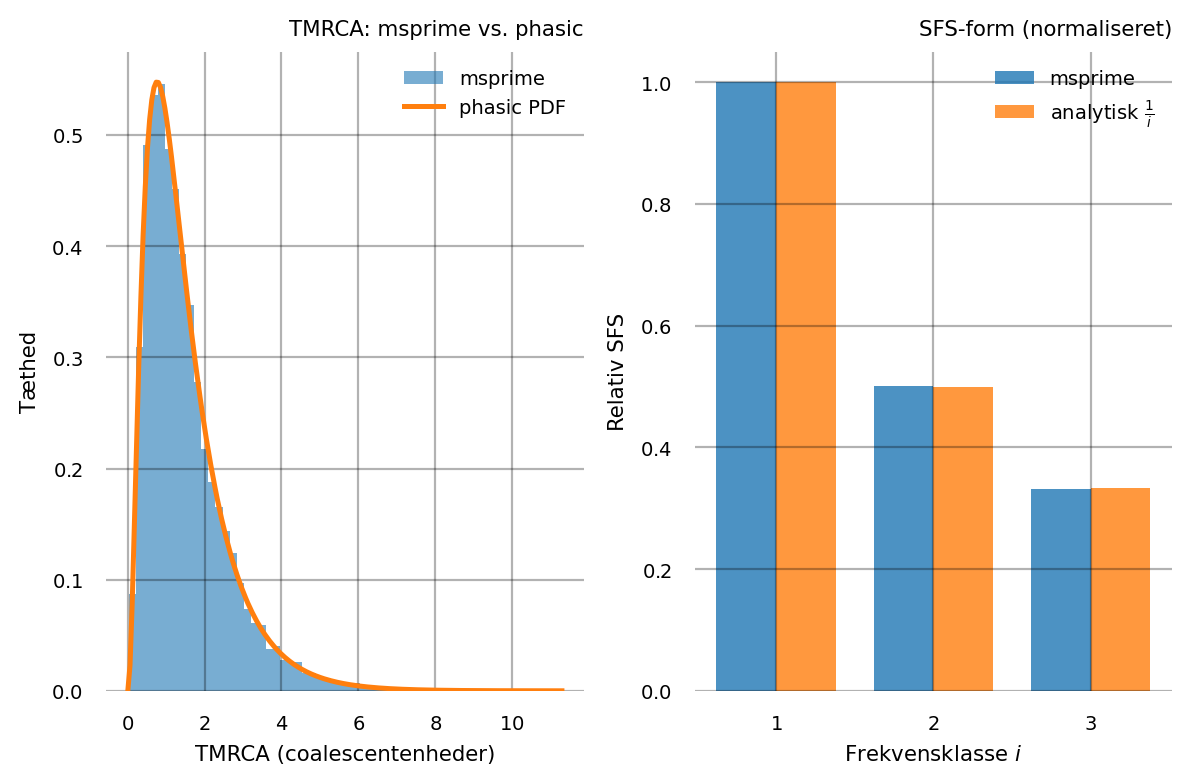

In [34]:
#| label: fig-msprime-validering
#| fig-cap: 'Validering af phasic mod msprime med $n=4$ og $3000$ simulerede genealogier. Venstre: histogram af simulerede TMRCA-værdier (blå) sammenlignet med den analytiske PDF fra phasic (orange kurve), x-aksen viser TMRCA i coalescent-enheder og y-aksen tæthed. Højre: normaliseret SFS fra msprime (blå) og analytisk forventning $1/i$ (orange) for frekvensklasse $i=1,2,3$, y-aksen viser relativ SFS normaliseret til singletons.'
#| fig-width: 6
#| fig-height: 3

with sns.plotting_context("paper", font_scale=0.8):
    fig, axes = plt.subplots(1, 2, figsize=(6, 4))

    for ax in axes:
        ax.grid(alpha=0.3)

    x = np.linspace(0, tmrca_samples.max(), 200)
    axes[0].hist(tmrca_samples, bins=60, density=True, alpha=0.6, label='msprime')
    axes[0].plot(x, graph.pdf(x), 'C1', lw=1.8, label='phasic PDF')
    axes[0].set_xlabel('TMRCA (coalescentenheder)')
    axes[0].set_ylabel('Tæthed')
    axes[0].set_title('TMRCA: msprime vs. phasic')
    axes[0].legend()

    i_idx = np.arange(1, nr_samples)
    analytic = np.array([1/i for i in i_idx]); analytic = analytic / analytic[0]
    width = 0.38
    axes[1].bar(i_idx - width/2, sfs_norm, width, label='msprime', alpha=0.8)
    axes[1].bar(i_idx + width/2, analytic, width, label=r'analytisk $\frac{1}{i}$', alpha=0.8)
    axes[1].set_xlabel(r'Frekvensklasse $i$')
    axes[1].set_ylabel('Relativ SFS')
    axes[1].set_title('SFS-form (normaliseret)')
    axes[1].set_xticks(i_idx)
    axes[1].legend()

    plt.tight_layout()
    plt.show()